# First impediment - images with multiple faces

## 1. Setup

In [19]:
import sys
import random
import shutil
import warnings
from pathlib import Path
import json

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import auc, roc_curve, confusion_matrix, ConfusionMatrixDisplay

sys.path.insert(0, str(Path('..').resolve()))

from src.model import get_insightface_model, get_embedding, cosine_similarity
from src.database import EmbeddingDB
from src.authorization import identify
from src.metrics import compute_far_frr, compute_roc, eer, plot_roc, plot_far_frr_vs_threshold
from src.utils import list_images

warnings.filterwarnings('ignore')

SEED             = 44
DEFAULT_THRESH   = 0.4
TEST_DIR         = Path('../data/enrolled_test')

random.seed(SEED)
np.random.seed(SEED)

print('Loading model...')
app = get_insightface_model('buffalo_l', ctx_id=0)
db  = EmbeddingDB.from_file()

enrolled_users = set(db.get_all_users())
print(f'Enrolled users in DB : {len(enrolled_users)}')
print(f'Test directory       : {TEST_DIR.resolve()}')

Loading model...
Enrolled users in DB : 100
Test directory       : /home/drzewo/szt_mag/face/data/enrolled_test


## 2. Prepare multiple face per image data

In [20]:
DATA_ROOT          = Path('../data')
ENROLLED_DIR       = DATA_ROOT / 'enrolled'
ENROLLED_TEST      = DATA_ROOT / 'enrolled_test'
MULTIPLE_FACES_DIR = DATA_ROOT / 'multiple_faces'
SYNTH_CLEAN_DIR    = MULTIPLE_FACES_DIR / 'synth_clean'
SYNTH_HARD_DIR     = MULTIPLE_FACES_DIR / 'synth_hard'

TEST_DIR = DATA_ROOT / 'test'

[PosixPath('../data/test/Al_Pacino/Al_Pacino_1798_962.jpeg'), PosixPath('../data/test/Al_Pacino/Al_Pacino_1799_963.jpeg'), PosixPath('../data/test/Al_Pacino/Al_Pacino_1800_964.jpeg'), PosixPath('../data/test/Al_Pacino/Al_Pacino_1803_966.jpeg'), PosixPath('../data/test/Al_Pacino/Al_Pacino_1811_973.jpeg'), PosixPath('../data/test/Al_Pacino/Al_Pacino_1814_975.jpeg'), PosixPath('../data/test/Al_Pacino/Al_Pacino_1817_978.jpeg'), PosixPath('../data/test/Al_Pacino/Al_Pacino_1819_980.jpeg'), PosixPath('../data/test/Al_Pacino/Al_Pacino_1820_981.jpeg'), PosixPath('../data/test/Al_Pacino/Al_Pacino_1822_983.jpeg'), PosixPath('../data/test/Al_Pacino/Al_Pacino_1825_985.jpeg'), PosixPath('../data/test/Al_Pacino/Al_Pacino_1826_986.jpeg'), PosixPath('../data/test/Al_Pacino/Al_Pacino_1831_990.jpeg'), PosixPath('../data/test/Al_Pacino/Al_Pacino_1833_992.jpeg'), PosixPath('../data/test/Al_Pacino/Al_Pacino_1834_993.jpeg'), PosixPath('../data/test/Al_Pacino/Al_Pacino_1844_999.jpeg'), PosixPath('../data/test

2651

<Figure size 640x480 with 0 Axes>

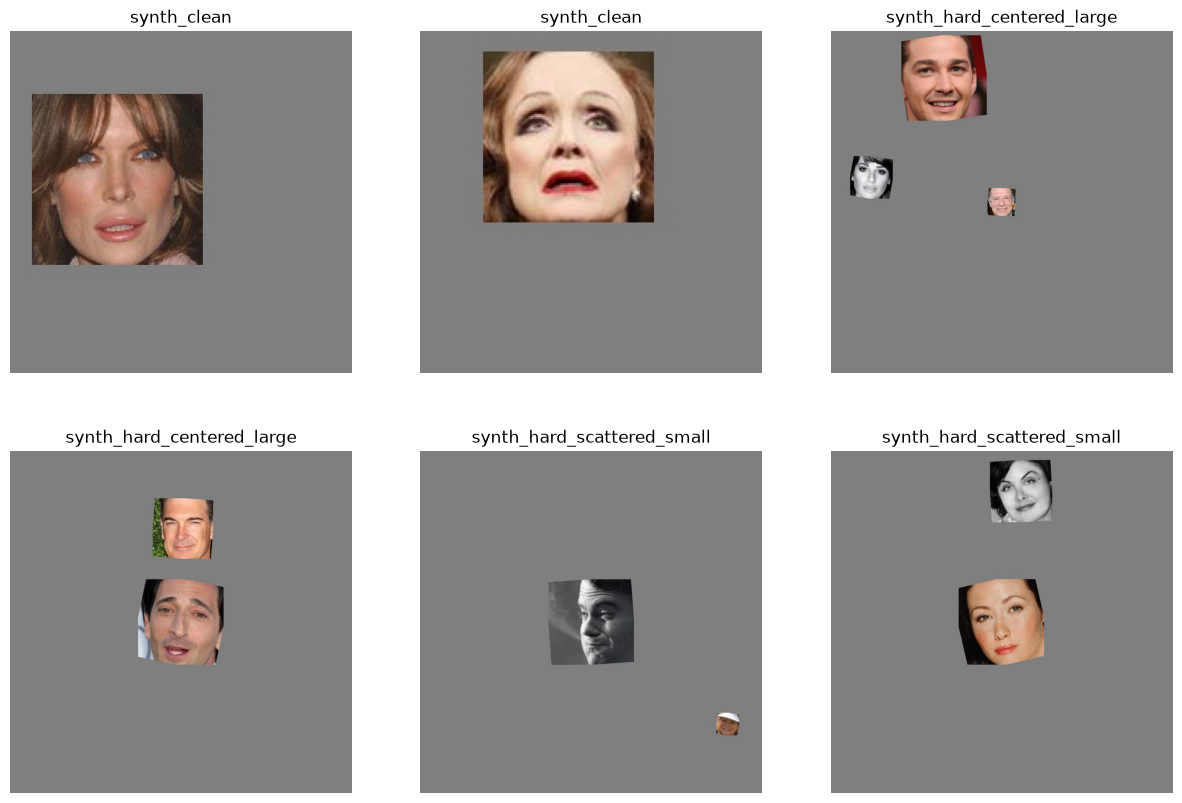

In [22]:
# Prepare synthetic clean / hard image datasets
NUM_CLEAN          = 10
NUM_HARD           = 20
SCALE_RANGE        = (0.8, 1.2)
HARD_FACE_COUNTS   = [2, 3]

face_paths = list_images(ENROLLED_DIR) + list_images(ENROLLED_TEST)
if len(face_paths) == 0:
    raise RuntimeError('No source faces found in enrolled directories.')

impostor_face_paths = list_images(TEST_DIR)
print(impostor_face_paths)

print(f'Found {len(face_paths)} source face crops.')

def make_background(face_size: tuple[int, int], fill_value: int = 127) -> np.ndarray:
    h, w = face_size
    return np.full((h * 2, w * 2, 3), fill_value, dtype=np.uint8)


def random_scale() -> float:
    return float(np.random.uniform(*SCALE_RANGE))


def scale_face(face: np.ndarray, scale: float) -> np.ndarray:
    h, w = face.shape[:2]
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    return cv2.resize(face, (new_w, new_h), interpolation=cv2.INTER_LINEAR)


def rotate_face(face: np.ndarray, angle_range: tuple[int, int] = (-15, 15)) -> np.ndarray:
    angle = random.uniform(*angle_range)
    h, w = face.shape[:2]
    center = (w // 2, h // 2)
    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(face, matrix, (w, h), borderValue=(127, 127, 127))
    return rotated


def random_position(bg_shape: tuple[int, int, int], face_shape: tuple[int, int, int]) -> tuple[int, int]:
    bg_h, bg_w = bg_shape[:2]
    face_h, face_w = face_shape[:2]
    x = random.randint(0, max(1, bg_w - face_w))
    y = random.randint(0, max(1, bg_h - face_h))
    return x, y


def bbox_overlap(a: tuple[int, int, int, int], b: tuple[int, int, int, int]) -> float:
    x1 = max(a[0], b[0])
    y1 = max(a[1], b[1])
    x2 = min(a[2], b[2])
    y2 = min(a[3], b[3])
    if x2 <= x1 or y2 <= y1:
        return 0.0
    inter = (x2 - x1) * (y2 - y1)
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    return inter / area_a


def place_face(bg: np.ndarray, face: np.ndarray, existing_boxes: list[tuple[int, int, int, int]], allow_overlap: float = 0.0) -> tuple[np.ndarray, tuple[int, int, int, int], bool]:
    """Place face on background, returning (bg, box, placed_successfully)"""
    max_attempts = 100
    for _ in range(max_attempts):
        x, y = random_position(bg.shape, face.shape)
        box = (x, y, x + face.shape[1], y + face.shape[0])
        if all(bbox_overlap(box, other) <= allow_overlap for other in existing_boxes):
            bg[y:y + face.shape[0], x:x + face.shape[1]] = face
            return bg, box, True
    return bg, (0, 0, 0, 0), False


def build_clean_image(src_path: Path, dst_path: Path) -> str:
    face = cv2.imread(str(src_path))
    if face is None:
        raise FileNotFoundError(src_path)
    face = scale_face(face, random_scale())
    bg = make_background(face.shape[:2])
    x, y = random_position(bg.shape, face.shape)
    bg[y:y + face.shape[0], x:x + face.shape[1]] = face
    cv2.imwrite(str(dst_path), bg, [cv2.IMWRITE_JPEG_QUALITY, 95])
    return src_path.parent.name


def build_hard_image(
    enrolled_paths: list[Path],
    impostor_paths: list[Path],
    dst_path: Path,
    group_type: str = "centered_large",
) -> list[str]:
    """Build hard image with multiple faces.
    
    group_type:
    - 'centered_large': Enrolled user in center, larger than other faces
    - 'scattered_small': Enrolled user scattered and much smaller than other faces
      (claimed user should be smallest and farthest from center)
    """
    num_faces = random.choice(HARD_FACE_COUNTS)
    enrolled_groups = _group_paths_by_user(enrolled_paths)
    impostor_groups = _group_paths_by_user(impostor_paths)

    enrolled_user = random.choice(
        list(enrolled_groups.keys())
    )

    num_impostors = num_faces - 1

    available_impostors = list(impostor_groups.keys())

    other_users = random.sample(
        available_impostors,
        min(num_impostors, len(available_impostors))
    )

    enrolled_path = None
    enrolled_original = None
    enrolled_faces = enrolled_groups[enrolled_user]
    if enrolled_faces:
        enrolled_path = random.choice(enrolled_faces)
        enrolled_original = cv2.imread(str(enrolled_path))

    faces: list[tuple[str, np.ndarray, float]] = []  # (user, face, scale)

    def place_face_at_center(
        bg: np.ndarray,
        face: np.ndarray,
    ) -> tuple[np.ndarray, tuple[int, int, int, int]]:
        bg_h, bg_w = bg.shape[:2]

        x = (bg_w - face.shape[1]) // 2
        y = (bg_h - face.shape[0]) // 2

        bg[y:y + face.shape[0], x:x + face.shape[1]] = face

        box = (
            x,
            y,
            x + face.shape[1],
            y + face.shape[0],
        )

        return bg, box
    
    def place_face_outside_center(
        bg: np.ndarray,
        face: np.ndarray,
        existing_boxes: list[tuple[int, int, int, int]],
        allow_overlap: float = 0.0,
        center_exclusion_ratio: float = 0.35,
        attempts: int = 1000,
    ) -> tuple[np.ndarray, tuple[int, int, int, int], bool]:

        bg_h, bg_w = bg.shape[:2]

        cx1 = bg_w * center_exclusion_ratio
        cx2 = bg_w * (1.0 - center_exclusion_ratio)

        cy1 = bg_h * center_exclusion_ratio
        cy2 = bg_h * (1.0 - center_exclusion_ratio)

        for _ in range(attempts):

            x, y = random_position(bg.shape, face.shape)

            box = (
                x,
                y,
                x + face.shape[1],
                y + face.shape[0],
            )

            if not all(
                bbox_overlap(box, other) <= allow_overlap
                for other in existing_boxes
            ):
                continue

            fx = x + face.shape[1] / 2
            fy = y + face.shape[0] / 2

            inside_center = (
                cx1 <= fx <= cx2
                and
                cy1 <= fy <= cy2
            )

            if inside_center:
                continue

            bg[y:y + face.shape[0], x:x + face.shape[1]] = face

            return bg, box, True

        return bg, (0, 0, 0, 0), False

    other_faces: list[tuple[str, np.ndarray, float]] = []
    other_scales: list[float] = []
    for user in other_users:
        user_faces = impostor_groups[user]
        if not user_faces:
            continue
        path = random.choice(user_faces)
        face = cv2.imread(str(path))
        if face is None:
            continue
        if group_type == 'centered_large':
            other_scale = random.uniform(0.8, 1.0)  # Smaller than enrolled
        else:  # scattered_small
            other_scale = random.uniform(0.9, 1.3)
        face = scale_face(face, other_scale)
        face = rotate_face(face)
        other_faces.append((user, face, other_scale))
        other_scales.append(other_scale)

    if group_type == 'scattered_small' and enrolled_original is not None and other_scales:
        min_other_scale = min(other_scales)

        enrolled_scale = min_other_scale * random.uniform(
            0.45,
            0.65,
        )
        enrolled_face = scale_face(enrolled_original, enrolled_scale)
        enrolled_face = rotate_face(enrolled_face)
        faces.append((enrolled_user, enrolled_face, enrolled_scale))
    elif enrolled_original is not None:
        if group_type == 'centered_large':
            enrolled_scale = random.uniform(1.0, 1.2)
        else:
            enrolled_scale = random.uniform(0.5, 0.7)
        enrolled_face = scale_face(enrolled_original, enrolled_scale)
        enrolled_face = rotate_face(enrolled_face)
        faces.append((enrolled_user, enrolled_face, enrolled_scale))

    faces.extend(other_faces)

    if len(faces) < 2:
        raise RuntimeError('Failed to load enough distinct source faces for hard image.')

    # Create background
    max_h = max(face.shape[0] for _, face, _ in faces)
    max_w = max(face.shape[1] for _, face, _ in faces)
    bg_w = 4 * max_w
    bg_h = 4 * max_h
    bg = np.full((bg_h, bg_w, 3), 127, dtype=np.uint8)

    # Place faces
    boxes: list[tuple[int, int, int, int]] = []
    placed_faces: list[str] = []

    if group_type == 'centered_large':
        # Place enrolled user in center
        enrolled_user_idx = 0
        enrolled_face = faces[enrolled_user_idx][1]
        center_x = (bg_w - enrolled_face.shape[1]) // 2
        center_y = (bg_h - enrolled_face.shape[0]) // 2
        bg[center_y:center_y + enrolled_face.shape[0], center_x:center_x + enrolled_face.shape[1]] = enrolled_face
        boxes.append((center_x, center_y, center_x + enrolled_face.shape[1], center_y + enrolled_face.shape[0]))
        placed_faces.append(faces[enrolled_user_idx][0])

        # Place other faces around, ensuring no overlap
        for i in range(1, len(faces)):
            user, face, _ = faces[i]
            _, box, placed = place_face(bg, face, boxes, allow_overlap=0.0)
            if placed:
                boxes.append(box)
                placed_faces.append(user)
    else:  # scattered_small
        # --------------------------------------------------
        # Place one impostor exactly in the center.
        # This is the face the heuristic should select.
        # --------------------------------------------------

        center_user, center_face, _ = faces[1]

        bg, center_box = place_face_at_center(
            bg,
            center_face,
        )

        boxes.append(center_box)
        placed_faces.append(center_user)

        # --------------------------------------------------
        # Place remaining impostors.
        # --------------------------------------------------

        for user, face, _ in faces[2:]:

            _, box, placed = place_face(
                bg,
                face,
                boxes,
                allow_overlap=0.0,
            )

            if placed:
                boxes.append(box)
                placed_faces.append(user)

        # --------------------------------------------------
        # Place enrolled user outside center.
        # --------------------------------------------------

        enrolled_user_name, enrolled_face, _ = faces[0]

        _, box, placed = place_face_outside_center(
            bg,
            enrolled_face,
            boxes,
            allow_overlap=0.0,
            center_exclusion_ratio=0.35,
        )

        if not placed:
            raise RuntimeError(
                "Failed to place enrolled face outside center."
            )

        boxes.append(box)
        placed_faces.append(enrolled_user_name)
    if group_type == "scattered_small":
        print("-----")
        print("enrolled:", enrolled_user_name)

        for idx, (user, box) in enumerate(zip(placed_faces, boxes)):
            x1, y1, x2, y2 = box

            area = (x2 - x1) * (y2 - y1)

            cx = (x1 + x2) / 2
            cy = (y1 + y2) / 2

            print(
                idx,
                user,
                "area=", area,
                "center=", (round(cx), round(cy)),
            )

    cv2.imwrite(str(dst_path), bg, [cv2.IMWRITE_JPEG_QUALITY, 95])
    return placed_faces


def _group_paths_by_user(src_paths: list[Path]) -> dict[str, list[Path]]:
    groups: dict[str, list[Path]] = {}
    for path in src_paths:
        groups.setdefault(path.parent.name, []).append(path)
    return groups


def build_clean_dataset(dst_dir: Path, count: int, src_paths: list[Path]) -> list[dict]:
    dst_dir.mkdir(parents=True, exist_ok=True)
    metadata: list[dict] = []
    for idx in range(count):
        dst_path = dst_dir / f'{idx:06d}.jpg'
        true_user = build_clean_image(random.choice(src_paths), dst_path)
        metadata.append({'path': dst_path, 'true_users': [true_user]})
        if (idx + 1) % 500 == 0 or idx == count - 1:
            print(f'  {idx + 1}/{count} images created in {dst_dir.name}')
    return metadata


def build_hard_dataset(
    dst_dir: Path,
    count: int,
    enrolled_paths: list[Path],
    impostor_paths: list[Path],
    group_type: str = "centered_large",
):
    dst_dir.mkdir(parents=True, exist_ok=True)
    metadata: list[dict] = []
    enrolled_groups = _group_paths_by_user(enrolled_paths)
    impostor_groups = _group_paths_by_user(impostor_paths)

    if not enrolled_groups:
        raise RuntimeError("No enrolled identities found.")

    if not impostor_groups:
        raise RuntimeError("No impostor identities found.")

    for idx in range(count):
        dst_path = dst_dir / f'{idx:06d}.jpg'
        chosen_users = build_hard_image(enrolled_paths, impostor_paths, dst_path, group_type=group_type)
        metadata.append({'path': dst_path, 'true_users': chosen_users})
        if (idx + 1) % 500 == 0 or idx == count - 1:
            print(f'  {idx + 1}/{count} images created in {dst_dir.name}')
    return metadata


print('Generating clean images...')
clean_meta = build_clean_dataset(SYNTH_CLEAN_DIR, NUM_CLEAN, face_paths)

print('Generating hard images (centered, large enrolled user)...')
SYNTH_HARD_CENTERED_DIR = MULTIPLE_FACES_DIR / 'synth_hard_centered_large'
hard_meta_centered = build_hard_dataset(SYNTH_HARD_CENTERED_DIR, NUM_HARD // 2, face_paths, impostor_face_paths, group_type='centered_large')

print('Generating hard images (scattered, small enrolled user)...')
SYNTH_HARD_SCATTERED_DIR = MULTIPLE_FACES_DIR / 'synth_hard_scattered_small'
hard_meta_scattered = build_hard_dataset(SYNTH_HARD_SCATTERED_DIR, NUM_HARD // 2, face_paths, impostor_face_paths, group_type='scattered_small')

hard_meta = hard_meta_centered + hard_meta_scattered

# Quick sample preview
sample_paths = [m['path'] for m in clean_meta[:2]] + [m['path'] for m in hard_meta_centered[:2]] + [m['path'] for m in hard_meta_scattered[:2]]
plt.tight_layout()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))    

for ax, path in zip(axes.flatten(), sample_paths):
    ax.axis('off')
    ax.set_title(path.parent.name)
    img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)

# Save metadata to JSON files
(SYNTH_CLEAN_DIR / 'metadata.json').write_text(json.dumps([{'path': str(m['path']), 'true_users': m['true_users']} for m in clean_meta]))
(SYNTH_HARD_CENTERED_DIR / 'metadata.json').write_text(json.dumps([{'path': str(m['path']), 'true_users': m['true_users']} for m in hard_meta_centered]))
(SYNTH_HARD_SCATTERED_DIR / 'metadata.json').write_text(json.dumps([{'path': str(m['path']), 'true_users': m['true_users']} for m in hard_meta_scattered]))
(MULTIPLE_FACES_DIR / 'hard_metadata_combined.json').write_text(json.dumps([{'path': str(m['path']), 'true_users': m['true_users']} for m in hard_meta]))

## 3. Compute scores

In [23]:
# Re-evaluate with full dataset and calculate comprehensive metrics
def evaluate_authentication_full(metadata: list[dict], label: str) -> pd.DataFrame:
    """Evaluate claimed-user verification on full dataset"""
    results: list[dict] = []
    for idx, entry in enumerate(metadata):
        img = cv2.imread(str(entry['path']))
        if img is None:
            results.append({
                'dataset': label,
                'image': str(entry['path'].name),
                'true_users': entry['true_users'],
                'claimed_user': entry['true_users'][0] if entry['true_users'] else None,
                'identified_user': None,
                'identified_score': 0.0,
                'claimed_score': 0.0,
                'identified_correct': False,
                'verified_claimed': False,
            })
            continue

        probe = get_embedding(app, img)
        if probe is None:
            results.append({
                'dataset': label,
                'image': str(entry['path'].name),
                'true_users': entry['true_users'],
                'claimed_user': entry['true_users'][0] if entry['true_users'] else None,
                'identified_user': None,
                'identified_score': 0.0,
                'claimed_score': 0.0,
                'identified_correct': False,
                'verified_claimed': False,
            })
            continue

        claimed_user = entry['true_users'][0] if entry['true_users'] else None
        claimed_score = db.query_user(claimed_user, probe) if claimed_user else 0.0
        verified_claimed = claimed_score >= DEFAULT_THRESH

        identified_user, identified_score = identify(img, app, db, threshold=DEFAULT_THRESH)
        identified_correct = identified_user == claimed_user if identified_user else False

        results.append({
            'dataset': label,
            'image': str(entry['path'].name),
            'true_users': entry['true_users'],
            'claimed_user': claimed_user,
            'identified_user': identified_user,
            'identified_score': identified_score,
            'claimed_score': claimed_score,
            'identified_correct': identified_correct,
            'verified_claimed': verified_claimed,
        })

        if (idx + 1) % 50 == 0:
            print(f'  {label}: processed {idx + 1}/{len(metadata)} images')

    print(f'  {label}: completed {len(metadata)} images')
    return pd.DataFrame(results)


# Evaluate all datasets fully
print('Evaluating clean dataset...')
clean_auth_full = evaluate_authentication_full(clean_meta, 'clean')

print('Evaluating hard centered dataset...')
hard_auth_centered_full = evaluate_authentication_full(hard_meta_centered, 'hard_centered_large')

print('Evaluating hard scattered dataset...')
hard_auth_scattered_full = evaluate_authentication_full(hard_meta_scattered, 'hard_scattered_small')

# Calculate metrics for each dataset
metrics_results = []

for df, label in [
    (clean_auth_full, 'clean'),
    (hard_auth_centered_full, 'hard_centered_large'),
    (hard_auth_scattered_full, 'hard_scattered_small'),
]:
    tp = ((df['verified_claimed'] == True) & (df['identified_correct'] == True)).sum()
    fp = ((df['verified_claimed'] == True) & (df['identified_correct'] == False)).sum()
    tn = ((df['verified_claimed'] == False) & (df['identified_correct'] == False)).sum()
    fn = ((df['verified_claimed'] == False) & (df['identified_correct'] == True)).sum()

    total = len(df)
    accuracy = (tp + tn) / total if total > 0 else 0
    verification_pass_rate = df['verified_claimed'].mean()
    identification_accuracy = df['identified_correct'].mean()

    false_positives = (df['verified_claimed'] & ~df['identified_correct']).sum()
    false_negatives = (~df['verified_claimed'] & df['identified_correct']).sum()
    true_negatives = (~df['verified_claimed'] & ~df['identified_correct']).sum()
    true_positives = (df['verified_claimed'] & df['identified_correct']).sum()

    far = false_positives / (false_positives + true_negatives) if (false_positives + true_negatives) > 0 else 0
    frr = false_negatives / (false_negatives + true_positives) if (false_negatives + true_positives) > 0 else 0

    metrics_results.append({
        'dataset': label,
        'total_images': total,
        'accuracy': f'{accuracy:.4f}',
        'identification_accuracy': f'{identification_accuracy:.4f}',
        'verification_pass_rate': f'{verification_pass_rate:.4f}',
        'FAR': f'{far:.4f}',
        'FRR': f'{frr:.4f}',
        'TP': tp,
        'FP': fp,
        'TN': tn,
        'FN': fn,
    })

metrics_df = pd.DataFrame(metrics_results)
print('\n=== Full Metrics Summary ===')
print(metrics_df.to_string(index=False))

# Build a verification test using clean + centered as genuine and scattered as impostor
positive_scores = np.concatenate([
    clean_auth_full['claimed_score'].to_numpy(),
    hard_auth_centered_full['claimed_score'].to_numpy(),
])
negative_scores = hard_auth_scattered_full['claimed_score'].to_numpy()

scores = np.concatenate([positive_scores, negative_scores])
labels = np.concatenate([np.ones_like(positive_scores, dtype=int), np.zeros_like(negative_scores, dtype=int)])

far_at_thresh, frr_at_thresh, acc_at_thresh = compute_far_frr(scores, labels, DEFAULT_THRESH)
fpr, tpr, thresholds = compute_roc(scores, labels)
eer_val, eer_threshold = eer(fpr, tpr, thresholds)

print('\n=== Verification Evaluation (clean + centered genuine vs scattered impostor) ===')
print(f'Threshold: {DEFAULT_THRESH:.2f}')
print(f'Accuracy: {acc_at_thresh:.4f}')
print(f'FAR: {far_at_thresh:.4f}')
print(f'FRR: {frr_at_thresh:.4f}')
print(f'EER: {eer_val:.4f} at threshold {eer_threshold:.4f}')

# Specifically show scatter statistics
n_scatter_verified = hard_auth_scattered_full['verified_claimed'].sum()
print('\n=== Hard Scattered Small - Detailed Statistics ===')
print(f'Total images: {len(hard_auth_scattered_full)}')
print(f'Claimed-user verified (pass): {n_scatter_verified}')
print(f'Failed verified (reject): {len(hard_auth_scattered_full) - n_scatter_verified}')
print(f'Verification pass rate: {hard_auth_scattered_full['verified_claimed'].mean():.4f}')
print(f'Identification accuracy: {hard_auth_scattered_full['identified_correct'].mean():.4f}')
print(f'Claimed-score - Min: {hard_auth_scattered_full['claimed_score'].min():.4f}, Mean: {hard_auth_scattered_full['claimed_score'].mean():.4f}, Max: {hard_auth_scattered_full['claimed_score'].max():.4f}')

# Sample which face the model picks for hard scattered images
print('\n=== Scattered sample identification ===')
for idx, row in hard_auth_scattered_full.head(10).iterrows():
    print(f"{row['image']}: claimed={row['claimed_user']} identified={row['identified_user']} identified_score={row['identified_score']:.4f} claimed_score={row['claimed_score']:.4f}")


Evaluating clean dataset...
  clean: completed 10 images
Evaluating hard centered dataset...
  hard_centered_large: completed 10 images
Evaluating hard scattered dataset...
  hard_scattered_small: completed 10 images

=== Full Metrics Summary ===
             dataset  total_images accuracy identification_accuracy verification_pass_rate    FAR    FRR  TP  FP  TN  FN
               clean            10   1.0000                  1.0000                 1.0000 0.0000 0.0000  10   0   0   0
 hard_centered_large            10   1.0000                  0.9000                 0.9000 0.0000 0.0000   9   0   1   0
hard_scattered_small            10   1.0000                  0.0000                 0.0000 0.0000 0.0000   0   0  10   0

=== Verification Evaluation (clean + centered genuine vs scattered impostor) ===
Threshold: 0.40
Accuracy: 0.9667
FAR: 0.0000
FRR: 0.0500
EER: 0.0000 at threshold 0.0055

=== Hard Scattered Small - Detailed Statistics ===
Total images: 10
Claimed-user verified (pass):